In [1]:
import matplotlib.pyplot as plt
import joblib as jlb
import pandas as pd
from collections import Counter
from sklearn.metrics import silhouette_score
from Algorithm import CLARANS
from Dataprepare.data_processing import D
from Dataprepare.data_processing import data_pca
from utils.Clarans_fast_build import clarans_fast_build,clarans_silhouette_analysis

In [3]:
features=[
 'cash_advance',
 'cash_advance_frequency',
 'cash_advance_trx'
]
data=D[features].copy()
print(data.shape)
print(data.tail(1))

(8636, 3)
      cash_advance  cash_advance_frequency  cash_advance_trx
8635       0.42096                1.090332          0.265283


k=2, Silhouette Score: 0.7285
k=3, Silhouette Score: 0.7343
k=4, Silhouette Score: 0.6704
k=5, Silhouette Score: 0.6587
k=6, Silhouette Score: 0.6507
k=7, Silhouette Score: 0.6353
k=8, Silhouette Score: 0.6221


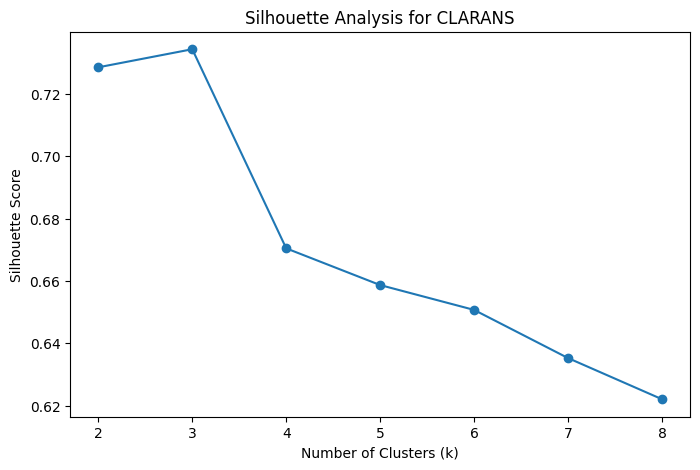

In [3]:
clarans_silhouette_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)


In [4]:
#xay dung model clarans
k = 3
n_local=5
max_nei=5
Clarans_model = CLARANS(data, k, n_local, max_nei)
Clarans_model.fit()

In [5]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[13, 30, 31, 34, 42, 44, 46, 50, 52, 57, 59, 65, 71, 77, 81, 83, 85, 86, 92, 96, 109, 112, 123, 129, 131, 138, 140, 142, 146, 148, 156, 166, 168, 179, 188, 191, 194, 203, 207, 209, 211, 212, 227, 234, 235, 242, 243, 249, 251, 253, 256, 258, 261, 269, 271, 274, 299, 311, 319, 326, 327, 346, 347, 348, 359, 362, 372, 375, 384, 388, 389, 390, 393, 396, 397, 400, 401, 408, 411, 415, 421, 422, 426, 427, 430, 436, 441, 456, 457, 463, 471, 489, 491, 493, 502, 511, 512, 518, 521, 523, 534, 543, 546, 555, 559, 572, 575, 578, 582, 588, 592, 597, 598, 599, 615, 622, 623, 628, 629, 632, 635, 636, 641, 648, 651, 653, 665, 667, 670, 677, 679, 681, 690, 699, 703, 707, 717, 726, 731, 734, 735, 737, 739, 744, 756, 757, 769, 778, 785, 786, 806, 807, 810, 811, 814, 830, 840, 841, 845, 858, 871, 899, 913, 917, 918, 929, 935, 937, 939, 947, 949, 950, 956, 962, 966, 967, 978, 980, 982, 988, 990, 997, 1000, 1001, 1004, 1010, 1015, 1022, 1023, 1024, 1036, 1038, 1041, 1046, 1048, 1053, 1054, 1055, 10

In [6]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

   cash_advance  cash_advance_frequency  cash_advance_trx  cluster
0     -0.937894               -0.731226         -0.817000        1
1      1.518315                0.681686          0.768516        2
2     -0.937894               -0.731226         -0.817000        1
3     -0.937894               -0.731226         -0.817000        1
4     -0.937894               -0.731226         -0.817000        1

Kích thước clusters: Counter({1: 4431, 2: 2569, 0: 1636})

2 clusters lớn nhất: [(1, 4431), (2, 2569)]


In [7]:
#silhouette score
sil_score = silhouette_score(data.drop(columns=['cluster']), labels)
Clarans_model.sihouette_score_=sil_score
print(f'Silhouette Score: {Clarans_model.sihouette_score_:.4f}')

Silhouette Score: 0.7090


In [8]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [9]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

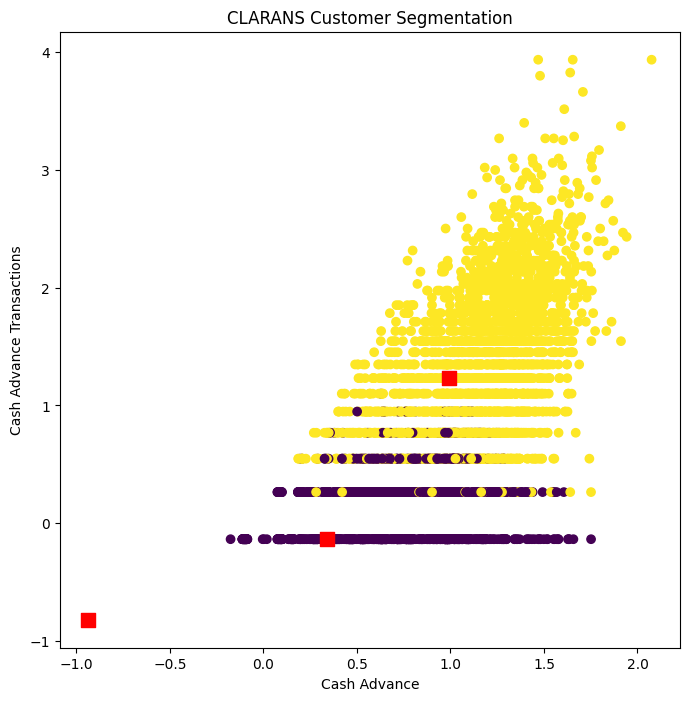

In [10]:
#hien thi model
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(data['cash_advance'],
            data['cash_advance_trx'],
            c=data['cluster'])

plt.scatter(medoid_points['cash_advance'],
            medoid_points['cash_advance_trx'],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Cash Advance")
plt.ylabel("Cash Advance Transactions")
plt.title("CLARANS Customer Segmentation")

plt.show()

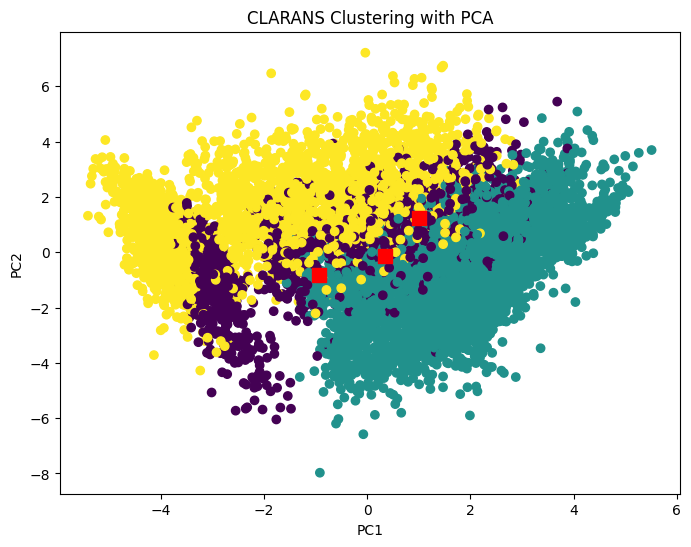

In [11]:
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=labels)
plt.scatter(medoid_points['cash_advance'],
            medoid_points['cash_advance_trx'],
            marker='s',
            s=100,color='red'
            )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()

k=2, Silhouette Score: 0.2965
k=3, Silhouette Score: 0.3591
k=4, Silhouette Score: 0.3139
k=5, Silhouette Score: 0.3125
k=6, Silhouette Score: 0.2904
k=7, Silhouette Score: 0.2998
k=8, Silhouette Score: 0.2817


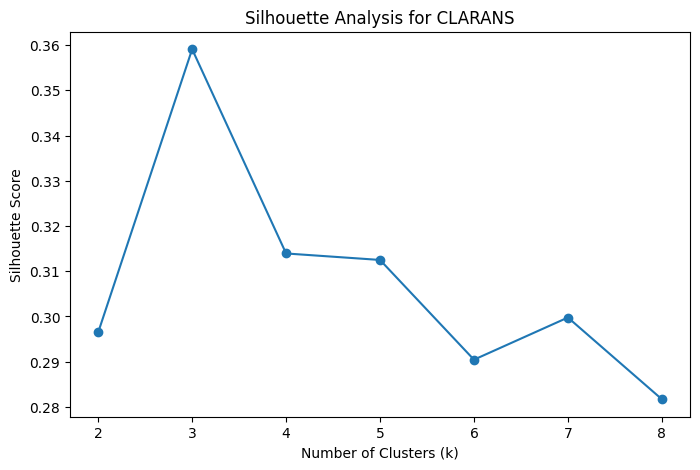

Silhouette Score: 0.3704


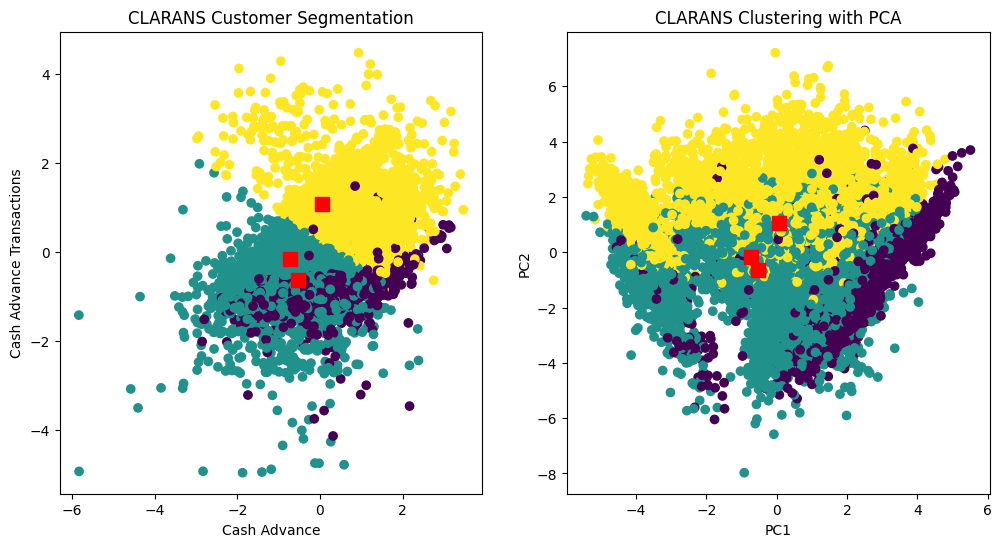

In [ ]:
k = 3
n_local=5
max_nei=5
features=[
 'payments',
 'minimum_payments',
 'prc_full_payment'
]
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_fast_build(datafast,k,n_local,max_nei,'payments','minimum_payments',data_pca)